# OnKith — PII Span Detection: Evaluation and Quantisation Trade-off

**What this notebook is.** A reproducible evaluation of an already-trained
4-layer TinyBERT token classifier that detects personally identifiable
information (PII) spans in English text. It loads the finished model, scores it
on a held-out test split, compares the FP32 and INT8 ONNX variants on quality,
size, latency and memory, and reports where the model fails.

**What this notebook is not.** It does not train anything — no fine-tuning loop,
no hyperparameter search, no checkpointing. It contains no product code, no
deployment integration, no audio pipeline, and no user data. Model weights are
not distributed with this repository (see the configuration cell below).

Everything downstream of the model — speech recognition, buffering, span
merging, the device runtime — belongs to the wider OnKith system and is out of
scope here.

In [1]:
%matplotlib inline

import gc
import json
import os
import platform
import random
import re
import subprocess
import sys
import time
from collections import Counter, defaultdict
from importlib.metadata import version as package_version
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import psutil
import torch
import transformers
from datasets import load_dataset
from seqeval.metrics import (
    classification_report as seqeval_classification_report,
    f1_score as seqeval_f1_score,
    precision_score as seqeval_precision_score,
    recall_score as seqeval_recall_score,
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from transformers import AutoModelForTokenClassification, AutoTokenizer

# Keep committed notebook outputs readable: no download/progress-bar spam.
transformers.utils.logging.set_verbosity_error()
try:
    import datasets
    datasets.disable_progress_bars()
except Exception:
    pass

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

virtual_memory = psutil.virtual_memory()
try:
    cpu_name = subprocess.run(
        ["wmic", "cpu", "get", "name"],
        capture_output=True, text=True, timeout=30,
    ).stdout.split("\n")[1].strip()
except Exception:
    cpu_name = platform.processor()

print("Environment")
print(f"  python            : {platform.python_version()}")
print(f"  torch             : {torch.__version__}")
print(f"  transformers      : {transformers.__version__}")
print(f"  onnxruntime       : {ort.__version__}")
print(f"  numpy             : {np.__version__}")
print(f"  seqeval           : {package_version('seqeval')}")
print(f"  matplotlib        : {matplotlib.__version__}")
print()
print("Hardware")
print(f"  CPU               : {cpu_name}")
print(f"  logical cores     : {os.cpu_count()}")
print(f"  total RAM         : {virtual_memory.total / 1024 ** 3:.1f} GiB")
print(f"  available RAM     : {virtual_memory.available / 1024 ** 3:.1f} GiB")
print(f"  OS                : {platform.system()} {platform.release()}")
print()
print(f"Random seed (python, numpy, torch): {SEED}")

<site-packages>\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment
  python            : 3.11.9
  torch             : 2.11.0+cu128
  transformers      : 5.13.1
  onnxruntime       : 1.27.0
  numpy             : 2.4.6
  seqeval           : 1.2.2
  matplotlib        : 3.11.0

Hardware
  CPU               : 
  logical cores     : 20
  total RAM         : 15.6 GiB
  available RAM     : 4.4 GiB
  OS                : Windows 10

Random seed (python, numpy, torch): 42


## 1. Configuration

**Model weights are not distributed with this repository.** This is deliberate:
the trained weights are a team asset and are not mine alone to publish. To run
this notebook you must point `MODEL_DIR` at a local directory holding the
artefacts, laid out as:

```text
<MODEL_DIR>/
├── onnx/model_fp32.onnx
├── onnx/model_int8.onnx
├── pytorch/config.json
├── pytorch/model.safetensors
├── tokenizer/tokenizer.json
├── tokenizer/tokenizer_config.json
└── config/id2label.json
```

`MODEL_DIR` is the only path that needs changing. Everything else — the dataset,
the split construction, the label schema — is resolved from pinned identifiers
below and is fully reproducible without any local files.

In [2]:
# The one path to change when running locally.
MODEL_DIR = Path("./models")

RESULTS_DIR = Path("./results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Pinned data and base-model identifiers — these fix what "the test split" means.
DATASET_NAME = "ai4privacy/pii-masking-openpii-1.5m"
DATASET_REVISION = "a785eb528e28be2693c3718a27e066970de5dadb"
BASE_MODEL_NAME = "huawei-noah/TinyBERT_General_4L_312D"
BASE_MODEL_REVISION = "34707a33cd59a94ecde241ac209bf35103691b43"

# Evaluation protocol — identical to the protocol used during training.
EVAL_BATCH_SIZE = 16
PAD_TO_MULTIPLE_OF = 8
OVERFLOW_STRIDE = 128

# Latency benchmark protocol.
LATENCY_ITERATIONS = 250
LATENCY_WARMUP = 25
BENCHMARK_THREADS = 1
BENCHMARK_BATCH_SIZE = 1

FP32_ONNX_PATH = MODEL_DIR / "onnx" / "model_fp32.onnx"
INT8_ONNX_PATH = MODEL_DIR / "onnx" / "model_int8.onnx"
PYTORCH_DIR = MODEL_DIR / "pytorch"
TOKENIZER_DIR = MODEL_DIR / "tokenizer"

for required_path in [FP32_ONNX_PATH, INT8_ONNX_PATH, PYTORCH_DIR, TOKENIZER_DIR]:
    if not required_path.exists():
        raise FileNotFoundError(
            f"{required_path} is missing. Set MODEL_DIR to a local directory "
            "containing the model artefacts; weights are not distributed here."
        )

HARDWARE_CAPTION = (
    "Measured on Intel Core i7-13700H (laptop CPU), single-threaded, "
    "batch size 1."
)

print("MODEL_DIR :", MODEL_DIR)
print("Dataset   :", f"{DATASET_NAME} @ {DATASET_REVISION}")
print("Base model:", f"{BASE_MODEL_NAME} @ {BASE_MODEL_REVISION}")

MODEL_DIR : models
Dataset   : ai4privacy/pii-masking-openpii-1.5m @ a785eb528e28be2693c3718a27e066970de5dadb
Base model: huawei-noah/TinyBERT_General_4L_312D @ 34707a33cd59a94ecde241ac209bf35103691b43


## 2. Label schema

The classifier uses **BIO** tagging (not BIOES). Each entity type contributes a
`B-` and an `I-` label, plus a single shared `O`. The schema was derived from the
entity types actually present in the training portion of the data, not from the
dataset publisher's headline taxonomy.

In [3]:
with (MODEL_DIR / "config" / "id2label.json").open(encoding="utf-8") as file:
    raw_id2label = json.load(file)

id2label = {int(key): value for key, value in raw_id2label.items()}
label_list = [id2label[label_id] for label_id in sorted(id2label)]
label2id = {label: label_id for label_id, label in id2label.items()}
num_labels = len(label_list)

entity_types = sorted({label[2:] for label in label_list if label != "O"})
training_entity_types = set(entity_types)

print(f"Tagging scheme : BIO")
print(f"Total labels   : {num_labels}  (O + {len(entity_types)} types x 2)")
print(f"Entity types   : {len(entity_types)}")
print()
for row_start in range(0, len(entity_types), 4):
    print("  " + "  ".join(f"{name:<18}" for name in entity_types[row_start:row_start + 4]))

Tagging scheme : BIO
Total labels   : 67  (O + 33 types x 2)
Entity types   : 33

  ACCOUNTNUM          AGE                 ALLERGIES           AMOUNT            
  BANKNAME            BUILDINGNUM         CITY                COUNTRY           
  CREDITCARDNUMBER    CURRENCY            DATE                DRIVERLICENSENUM  
  EMAIL               GENDER              GIVENNAME           IDCARDNUM         
  IPV4                ORGANISATION        PASSPORTNUM         SALARY            
  SEX                 SOCIALNUM           STREET              SURNAME           
  TAXNUM              TELEPHONENUM        TIME                TIMEZONE          
  TITLE               URL                 USERNAME            WEIGHT            
  ZIPCODE           


## 3. Test split

The dataset is loaded from Hugging Face by ID **and revision**, so this cell
resolves to the same rows on any machine regardless of later changes to the
dataset's `main` branch.

The split used here is the dataset's **official `validation` split**, filtered to
English. It was never trained on and never used for model selection — the
training and model-selection splits were both carved out of the official `train`
split. One row is excluded because it contains an entity type that does not
appear in training at all, and which the model therefore has no label for.

In [4]:
dataset = load_dataset(DATASET_NAME, revision=DATASET_REVISION)
english_dataset = dataset.filter(lambda example: example["language"] == "en")

held_out_split = english_dataset["validation"]

unsupported_types = set()
unsupported_row_indices = []
for row_index, privacy_mask in enumerate(held_out_split["privacy_mask"]):
    row_types = {span["label"] for span in privacy_mask}
    unknown = row_types - training_entity_types
    if unknown:
        unsupported_types |= unknown
        unsupported_row_indices.append(row_index)

scored_indices = [
    row_index
    for row_index in range(len(held_out_split))
    if row_index not in set(unsupported_row_indices)
]
test_split = held_out_split.select(scored_indices)

print("Official splits (all languages):")
for split_name, split_data in dataset.items():
    print(f"  {split_name:<12}: {len(split_data):>9,} rows")
print()
print("English-only:")
for split_name, split_data in english_dataset.items():
    print(f"  {split_name:<12}: {len(split_data):>9,} rows")
print()
print(f"Held-out English validation split : {len(held_out_split):,} rows")
print(f"Excluded (unsupported entity type): {len(unsupported_row_indices):,} rows "
      f"{sorted(unsupported_types)}")
print(f"Scored test split                 : {len(test_split):,} rows")

Official splits (all languages):
  train       : 1,309,912 rows
  validation  :   326,463 rows

English-only:
  train       :   163,740 rows
  validation  :    40,909 rows

Held-out English validation split : 40,909 rows
Excluded (unsupported entity type): 1 rows ['HEIGHT']
Scored test split                 : 40,908 rows


In [5]:
type_span_counts = Counter()
type_row_counts = Counter()
rows_without_pii = 0

for privacy_mask in test_split["privacy_mask"]:
    type_span_counts.update(span["label"] for span in privacy_mask)
    type_row_counts.update({span["label"] for span in privacy_mask})
    rows_without_pii += int(not privacy_mask)

annotated_span_total = sum(type_span_counts.values())

print(f"Rows                     : {len(test_split):,}")
print(f"Rows with no PII span    : {rows_without_pii:,}")
print(f"Annotated spans (raw)    : {annotated_span_total:,}")
print(f"Entity types present     : {len(type_span_counts)} of {len(entity_types)}")
print()
print(f"{'Entity type':<20}{'spans':>10}{'% spans':>10}{'rows':>10}")
print("-" * 50)
for entity_type, span_count in type_span_counts.most_common():
    print(f"{entity_type:<20}{span_count:>10,}{100 * span_count / annotated_span_total:>9.3f}%"
          f"{type_row_counts[entity_type]:>10,}")

absent_types = sorted(training_entity_types - set(type_span_counts))
print()
print(f"Trained types with zero test support ({len(absent_types)}): {absent_types}")

Rows                     : 40,908
Rows with no PII span    : 9
Annotated spans (raw)    : 311,477
Entity types present     : 29 of 33

Entity type              spans   % spans      rows
--------------------------------------------------
GIVENNAME               37,702   12.104%    29,362
DATE                    37,412   12.011%    28,471
SURNAME                 32,068   10.295%    26,582
EMAIL                   22,891    7.349%    21,724
CITY                    21,496    6.901%    20,105
TITLE                   21,077    6.767%    19,199
TELEPHONENUM            16,823    5.401%    16,208
STREET                  15,297    4.911%    15,047
AGE                     15,189    4.876%    14,037
BUILDINGNUM             14,594    4.685%    14,402
ZIPCODE                 13,084    4.201%    12,996
IDCARDNUM               10,272    3.298%    10,237
CREDITCARDNUMBER         9,259    2.973%     8,705
DRIVERLICENSENUM         8,639    2.774%     8,604
GENDER                   8,578    2.754%     8,43

## 4. Preprocessing and label alignment

Character-offset span annotations are converted to token-level BIO labels using
the fast tokenizer's offset mapping. The rules below are the same ones used to
build the training data, so the labels scored here mean exactly what the model
was trained to predict:

- **Span normalisation.** Exact duplicate spans are dropped; overlapping spans of
  the *same* type are merged; whitespace-only spans are dropped; `AGE` spans that
  are a digit-fragment of a longer number are dropped as malformed annotations.
- **Multi-entity tokens.** When one token overlaps two different entities, the
  entity with the greatest character overlap wins, ties broken by earliest start.
- **Long input.** Text over the model's 512-token limit is re-encoded as
  overlapping windows so nothing is silently truncated. Entities that are only
  partially inside a window are masked out (`-100`) in that window and scored
  from the window that contains them whole.

In [6]:
tokenizer = AutoTokenizer.from_pretrained(
    TOKENIZER_DIR, local_files_only=True, use_fast=True
)
if not tokenizer.is_fast:
    raise RuntimeError("A fast tokenizer is required for offset-based alignment.")

with (PYTORCH_DIR / "config.json").open(encoding="utf-8") as file:
    pytorch_config = json.load(file)

supported_context_limit = int(pytorch_config["max_position_embeddings"])

print("Tokenizer            :", tokenizer.__class__.__name__)
print("Vocabulary size      :", tokenizer.vocab_size)
print("Context limit        :", supported_context_limit)
print("Model hidden size    :", pytorch_config["hidden_size"])
print("Model layers         :", pytorch_config["num_hidden_layers"])

Tokenizer            : BertTokenizer
Vocabulary size      : 30522
Context limit        : 512
Model hidden size    : 312
Model layers         : 4


In [7]:
def is_malformed_age_fragment(source_text, span_start, span_end, span_value, entity_type):
    if entity_type != "AGE" or not span_value.isdigit():
        return False
    has_digit_before = span_start > 0 and source_text[span_start - 1].isdigit()
    has_digit_after = span_end < len(source_text) and source_text[span_end].isdigit()
    return has_digit_before or has_digit_after


def normalize_span_annotations(source_text, validated_spans, counters):
    unique_spans = []
    seen_keys = set()
    for span in validated_spans:
        key = (span["start"], span["end"], span["label"])
        if key in seen_keys:
            counters["exact_duplicate_spans_removed"] += 1
            continue
        seen_keys.add(key)
        unique_spans.append(span.copy())

    spans_by_type = defaultdict(list)
    for span in unique_spans:
        spans_by_type[span["label"]].append(span)

    normalized = []
    for type_spans in spans_by_type.values():
        merged = []
        for span in sorted(type_spans, key=lambda item: (item["start"], item["end"])):
            if merged and span["start"] <= merged[-1]["end"]:
                merged[-1]["end"] = max(merged[-1]["end"], span["end"])
                merged[-1]["value"] = source_text[merged[-1]["start"]:merged[-1]["end"]]
                counters["same_type_spans_merged"] += 1
            else:
                merged.append(span.copy())
        normalized.extend(merged)

    return sorted(normalized, key=lambda span: (span["start"], span["end"], span["label"]))


def privacy_mask_to_bio_spans(source_text, privacy_mask, counters):
    validated = []
    for span in privacy_mask:
        span_value, span_start, span_end = span["value"], span["start"], span["end"]
        entity_type = span["label"]

        if source_text[span_start:span_end] != span_value:
            raise ValueError("Span bounds do not match source_text.")
        if entity_type not in training_entity_types:
            raise ValueError(f"Unknown entity type {entity_type!r}.")

        if span_value.isspace():
            counters["whitespace_only_spans_removed"] += 1
            continue
        if is_malformed_age_fragment(
            source_text, span_start, span_end, span_value, entity_type
        ):
            counters["malformed_age_spans_removed"] += 1
            continue

        validated.append({
            "value": span_value, "start": span_start,
            "end": span_end, "label": entity_type,
        })

    return [
        {**span,
         "entity_type": span["label"],
         "begin_label": f"B-{span['label']}",
         "inside_label": f"I-{span['label']}"}
        for span in normalize_span_annotations(source_text, validated, counters)
    ]


def resolve_token_entity_conflict(token_start, token_end, overlapping):
    scored = [
        (index, span, min(token_end, span["end"]) - max(token_start, span["start"]))
        for index, span in overlapping
    ]
    greatest = max(overlap for _, _, overlap in scored)
    best = [candidate for candidate in scored if candidate[2] == greatest]
    earliest = min(span["start"] for _, span, _ in best)
    best = [candidate for candidate in best if candidate[1]["start"] == earliest]
    if len(best) != 1:
        raise ValueError("Unresolved token/entity conflict.")
    return best[0][0], best[0][1]


def align_labels_to_offsets(bio_spans, offset_mapping, window_bounds):
    window_start, window_end = window_bounds
    fully_covered = {
        index for index, span in enumerate(bio_spans)
        if window_start <= span["start"] and span["end"] <= window_end
    }
    aligned_label_ids = []
    assigned = set()
    previous_index = None

    for token_start, token_end in offset_mapping:
        if token_start == token_end:
            aligned_label_ids.append(-100)
            previous_index = None
            continue

        overlapping = [
            (index, span) for index, span in enumerate(bio_spans)
            if token_start < span["end"] and token_end > span["start"]
        ]
        if not overlapping:
            aligned_label_ids.append(label2id["O"])
            previous_index = None
            continue

        if len(overlapping) == 1:
            span_index, span = overlapping[0]
        else:
            span_index, span = resolve_token_entity_conflict(
                token_start, token_end, overlapping
            )

        touches_incomplete = any(index not in fully_covered for index, _ in overlapping)
        if touches_incomplete:
            aligned_label_ids.append(-100)
            previous_index = None
        elif span_index == previous_index:
            aligned_label_ids.append(label2id[span["inside_label"]])
        else:
            aligned_label_ids.append(label2id[span["begin_label"]])

        if not touches_incomplete:
            assigned.add(span_index)
            previous_index = span_index

    return aligned_label_ids, assigned


def non_special_window_bounds(offset_mapping):
    visible = [
        (start, end) for start, end in offset_mapping if start != end
    ]
    return (visible[0][0], visible[-1][1]) if visible else (0, 0)

In [8]:
def tokenize_example_windows(source_text, privacy_mask, example_index, counters):
    bio_spans = privacy_mask_to_bio_spans(source_text, privacy_mask, counters)
    full_encoding = tokenizer(
        source_text, truncation=False, padding=False,
        return_attention_mask=True, return_offsets_mapping=True,
        return_token_type_ids=False,
    )

    if len(full_encoding["input_ids"]) <= supported_context_limit:
        windows = [{
            "input_ids": full_encoding["input_ids"],
            "attention_mask": full_encoding["attention_mask"],
            "offset_mapping": full_encoding["offset_mapping"],
        }]
    else:
        counters["oversized_rows_windowed"] += 1
        longest_entity_tokens = max(
            [len(tokenizer(span["value"], add_special_tokens=False)["input_ids"])
             for span in bio_spans] or [0]
        )
        content_limit = (
            supported_context_limit - tokenizer.num_special_tokens_to_add(pair=False)
        )
        stride = min(max(OVERFLOW_STRIDE, longest_entity_tokens), content_limit - 1)
        overflow = tokenizer(
            source_text, truncation=True, max_length=supported_context_limit,
            stride=stride, padding=False, return_attention_mask=True,
            return_offsets_mapping=True, return_overflowing_tokens=True,
            return_token_type_ids=False,
        )
        windows = [
            {"input_ids": input_ids, "attention_mask": attention_mask,
             "offset_mapping": offset_mapping}
            for input_ids, attention_mask, offset_mapping in zip(
                overflow["input_ids"], overflow["attention_mask"],
                overflow["offset_mapping"],
            )
        ]

    features = []
    assigned = set()
    for window_index, window in enumerate(windows):
        window_start, window_end = non_special_window_bounds(window["offset_mapping"])
        if window_index == 0:
            window_start = 0
        if window_index == len(windows) - 1:
            window_end = len(source_text)
        labels, window_assigned = align_labels_to_offsets(
            bio_spans, window["offset_mapping"], (window_start, window_end)
        )
        assigned.update(window_assigned)
        features.append({
            "input_ids": window["input_ids"],
            "attention_mask": window["attention_mask"],
            "labels": labels,
            "offset_mapping": [tuple(offset) for offset in window["offset_mapping"]],
            "example_index": int(example_index),
            "window_index": window_index,
        })

    if set(range(len(bio_spans))) - assigned:
        raise ValueError("A normalised span was never assigned to a token.")

    return features, bio_spans


alignment_counters = Counter()
test_features = []
reference_sequences = []
normalized_span_total = 0

start_time = time.perf_counter()
for example_index, example in enumerate(test_split):
    source_text = example["source_text"]
    features, bio_spans = tokenize_example_windows(
        source_text, example["privacy_mask"], example_index, alignment_counters
    )
    test_features.extend(features)
    normalized_span_total += len(bio_spans)

    full_encoding = tokenizer(
        source_text, truncation=False, padding=False,
        return_offsets_mapping=True, return_attention_mask=False,
        return_token_type_ids=False,
    )
    label_ids, _ = align_labels_to_offsets(
        bio_spans, full_encoding["offset_mapping"], (0, len(source_text))
    )
    valid_offsets, valid_labels = [], []
    for offset, label_id in zip(full_encoding["offset_mapping"], label_ids):
        if label_id != -100:
            valid_offsets.append(tuple(offset))
            valid_labels.append(id2label[label_id])
    reference_sequences.append({
        "example_index": example_index,
        "offsets": valid_offsets,
        "true_labels": valid_labels,
    })

elapsed = time.perf_counter() - start_time

print(f"Rows tokenised        : {len(test_split):,}  ({elapsed:.1f} s)")
print(f"Windows produced      : {len(test_features):,}")
print(f"Scored tokens         : {sum(len(r['true_labels']) for r in reference_sequences):,}")
print(f"Normalised BIO spans  : {normalized_span_total:,}")
print()
print("Annotation normalisation counters:")
for counter_name in sorted(alignment_counters):
    print(f"  {counter_name:<34}: {alignment_counters[counter_name]:,}")

Rows tokenised        : 40,908  (107.4 s)
Windows produced      : 40,920
Scored tokens         : 3,725,659
Normalised BIO spans  : 311,431

Annotation normalisation counters:
  malformed_age_spans_removed       : 45
  oversized_rows_windowed           : 12
  same_type_spans_merged            : 1


### 4.1 Span accounting

Two different counting paths exist in the evaluation, and they do not produce the
same total. This cell reconciles them explicitly rather than presenting one
number and hoping nobody checks.

- **Entity-level (seqeval) support** counts *normalised, typed* BIO spans.
- **Character-level privacy metrics** count *distinct `(start, end)` character
  bounds* from the raw annotations, ignoring the entity type.

In [9]:
raw_distinct_bounds = 0
for privacy_mask in test_split["privacy_mask"]:
    raw_distinct_bounds += len({(span["start"], span["end"]) for span in privacy_mask})

removed_and_merged = (
    alignment_counters["same_type_spans_merged"]
    + alignment_counters["whitespace_only_spans_removed"]
    + alignment_counters["malformed_age_spans_removed"]
    + alignment_counters["exact_duplicate_spans_removed"]
)
shared_bounds_across_types = annotated_span_total - raw_distinct_bounds

span_accounting = {
    "raw_annotated_spans": annotated_span_total,
    "raw_distinct_character_bounds": raw_distinct_bounds,
    "normalized_typed_bio_spans": normalized_span_total,
    "spans_removed_or_merged_by_normalization": removed_and_merged,
    "spans_sharing_identical_bounds_across_types": shared_bounds_across_types,
    "difference_bounds_minus_bio": raw_distinct_bounds - normalized_span_total,
}

print(f"{'Raw annotated spans':<52}{annotated_span_total:>10,}")
print(f"{'  minus spans sharing identical bounds across types':<52}"
      f"{-shared_bounds_across_types:>10,}")
print(f"{'= Distinct character bounds (privacy-metric denominator)':<52}"
      f"{raw_distinct_bounds:>10,}")
print()
print(f"{'Raw annotated spans':<52}{annotated_span_total:>10,}")
print(f"{'  minus spans removed or merged by normalisation':<52}"
      f"{-removed_and_merged:>10,}")
print(f"{'= Normalised typed BIO spans (seqeval support total)':<52}"
      f"{normalized_span_total:>10,}")
print()
print(f"{'Difference between the two denominators':<52}"
      f"{raw_distinct_bounds - normalized_span_total:>10,}"
      f"  ({100 * abs(raw_distinct_bounds - normalized_span_total) / raw_distinct_bounds:.3f}%)")

Raw annotated spans                                    311,477
  minus spans sharing identical bounds across types          0
= Distinct character bounds (privacy-metric denominator)   311,477

Raw annotated spans                                    311,477
  minus spans removed or merged by normalisation           -46
= Normalised typed BIO spans (seqeval support total)   311,431

Difference between the two denominators                     46  (0.015%)


## 5. Metric definitions

**Token-level** scores every scored subword position. `O` is excluded from the
PII micro-average, so the numbers describe PII detection rather than being
inflated by the ~78% of tokens that carry no PII.

**Entity-level (span)** scores whole spans via `seqeval`: a span counts as correct
only if its type *and* both boundaries match exactly. This is the number that
matters — token-level alone materially overstates NER-style performance, because
getting 3 of a 4-token name right scores well on tokens and is still a wrong span.

Both are reported throughout. Where a single headline number is quoted, it is
entity-level micro-F1.

In [10]:
def normalize_bio_sequence(label_sequence):
    normalized, repair_count, previous_label = [], 0, "O"
    for label in label_sequence:
        normalized_label = label
        if label.startswith("I-"):
            entity_type = label[2:]
            previous_type = (
                previous_label[2:] if previous_label.startswith(("B-", "I-")) else None
            )
            if previous_type != entity_type:
                normalized_label = f"B-{entity_type}"
                repair_count += 1
        normalized.append(normalized_label)
        previous_label = normalized_label
    return normalized, repair_count


def merge_window_predictions(window_records, references):
    predictions_by_example = {
        reference["example_index"]: {} for reference in references
    }
    for record in window_records:
        example_predictions = predictions_by_example[record["example_index"]]
        for offset, label_id, confidence in zip(
            record["offsets"], record["predicted_label_ids"], record["confidences"]
        ):
            if offset[0] == offset[1]:
                continue
            previous = example_predictions.get(offset)
            if previous is None or confidence > previous[1]:
                example_predictions[offset] = (int(label_id), float(confidence))

    true_sequences, predicted_sequences, total_repairs = [], [], 0
    for reference in references:
        example_predictions = predictions_by_example[reference["example_index"]]
        missing = [
            offset for offset in reference["offsets"] if offset not in example_predictions
        ]
        if missing:
            raise RuntimeError(f"{len(missing)} token offsets have no prediction.")
        raw_labels = [
            id2label[example_predictions[offset][0]] for offset in reference["offsets"]
        ]
        normalized, repairs = normalize_bio_sequence(raw_labels)
        true_sequences.append(reference["true_labels"])
        predicted_sequences.append(normalized)
        total_repairs += repairs
    return true_sequences, predicted_sequences, total_repairs


PII_LABELS = [label for label in label_list if label != "O"]


def compute_token_metrics(true_sequences, predicted_sequences):
    true_labels = [label for sequence in true_sequences for label in sequence]
    predicted_labels = [label for sequence in predicted_sequences for label in sequence]

    micro = precision_recall_fscore_support(
        true_labels, predicted_labels, labels=PII_LABELS,
        average="micro", zero_division=0,
    )
    macro = precision_recall_fscore_support(
        true_labels, predicted_labels, labels=PII_LABELS,
        average="macro", zero_division=0,
    )
    per_label_scores = precision_recall_fscore_support(
        true_labels, predicted_labels, labels=PII_LABELS, zero_division=0,
    )
    per_label = {
        label: {
            "precision": float(per_label_scores[0][index]),
            "recall": float(per_label_scores[1][index]),
            "f1": float(per_label_scores[2][index]),
            "support": int(per_label_scores[3][index]),
        }
        for index, label in enumerate(PII_LABELS)
    }
    return {
        "all_valid_token_accuracy": float(accuracy_score(true_labels, predicted_labels)),
        "pii_token_micro_precision": float(micro[0]),
        "pii_token_micro_recall": float(micro[1]),
        "pii_token_micro_f1": float(micro[2]),
        "pii_token_macro_precision": float(macro[0]),
        "pii_token_macro_recall": float(macro[1]),
        "pii_token_macro_f1": float(macro[2]),
        "per_label": per_label,
    }


def compute_entity_metrics(true_sequences, predicted_sequences):
    report = seqeval_classification_report(
        true_sequences, predicted_sequences, output_dict=True, zero_division=0
    )
    aggregate_rows = {"micro avg", "macro avg", "weighted avg"}
    per_entity_type = {
        entity_type: {
            "precision": float(values["precision"]),
            "recall": float(values["recall"]),
            "f1": float(values["f1-score"]),
            "support": int(values["support"]),
        }
        for entity_type, values in report.items()
        if entity_type not in aggregate_rows and isinstance(values, dict)
    }
    macro = report["macro avg"]
    return {
        "pii_entity_precision": float(
            seqeval_precision_score(true_sequences, predicted_sequences)
        ),
        "pii_entity_recall": float(
            seqeval_recall_score(true_sequences, predicted_sequences)
        ),
        "pii_entity_f1": float(
            seqeval_f1_score(true_sequences, predicted_sequences)
        ),
        "pii_entity_macro_precision": float(macro["precision"]),
        "pii_entity_macro_recall": float(macro["recall"]),
        "pii_entity_macro_f1": float(macro["f1-score"]),
        "per_entity_type": per_entity_type,
    }


def labels_to_character_spans(offsets, labels):
    spans, active = [], None
    for (token_start, token_end), label in zip(offsets, labels):
        if label == "O":
            active = None
            continue
        prefix, entity_type = label.split("-", maxsplit=1)
        if prefix == "B" or active is None or active["entity_type"] != entity_type:
            active = {"start": int(token_start), "end": int(token_end),
                      "entity_type": entity_type}
            spans.append(active)
        else:
            active["end"] = int(token_end)
    return spans


def compute_privacy_metrics(split_dataset, references, predicted_sequences):
    private_chars = masked_private = 0
    non_private_chars = masked_non_private = 0
    true_span_total = exact_matches = 0

    for example, reference, predicted_labels in zip(
        split_dataset, references, predicted_sequences
    ):
        text_length = len(example["source_text"])
        true_mask = np.zeros(text_length, dtype=bool)
        for span in example["privacy_mask"]:
            true_mask[span["start"]:span["end"]] = True

        predicted_spans = labels_to_character_spans(
            reference["offsets"], predicted_labels
        )
        predicted_mask = np.zeros(text_length, dtype=bool)
        for span in predicted_spans:
            predicted_mask[span["start"]:span["end"]] = True

        private_chars += int(true_mask.sum())
        masked_private += int((true_mask & predicted_mask).sum())
        non_private_chars += int((~true_mask).sum())
        masked_non_private += int(((~true_mask) & predicted_mask).sum())

        true_bounds = {(span["start"], span["end"]) for span in example["privacy_mask"]}
        predicted_bounds = {(span["start"], span["end"]) for span in predicted_spans}
        true_span_total += len(true_bounds)
        exact_matches += len(true_bounds & predicted_bounds)

    recall = masked_private / private_chars
    return {
        "private_character_recall": float(recall),
        "private_character_leakage_rate": float(1 - recall),
        "non_private_character_over_masking_rate": float(
            masked_non_private / non_private_chars
        ),
        "exact_span_recall": float(exact_matches / true_span_total),
        "private_characters": int(private_chars),
        "masked_private_characters": int(masked_private),
        "non_private_characters": int(non_private_chars),
        "masked_non_private_characters": int(masked_non_private),
        "true_spans": int(true_span_total),
        "exact_span_matches": int(exact_matches),
    }


def evaluate_sequences(true_sequences, predicted_sequences, repair_count):
    return {
        "token_level": compute_token_metrics(true_sequences, predicted_sequences),
        "entity_level": compute_entity_metrics(true_sequences, predicted_sequences),
        "privacy": compute_privacy_metrics(
            test_split, reference_sequences, predicted_sequences
        ),
        "invalid_bio_transitions_repaired": int(repair_count),
    }


print("Metric functions defined.")

Metric functions defined.


In [11]:
def build_batches(features, batch_size, pad_to_multiple_of):
    batches = []
    for start in range(0, len(features), batch_size):
        chunk = features[start:start + batch_size]
        longest = max(len(feature["input_ids"]) for feature in chunk)
        padded_length = ((longest + pad_to_multiple_of - 1) // pad_to_multiple_of
                         * pad_to_multiple_of)
        input_ids = np.zeros((len(chunk), padded_length), dtype=np.int64)
        attention_mask = np.zeros((len(chunk), padded_length), dtype=np.int64)
        for row_index, feature in enumerate(chunk):
            length = len(feature["input_ids"])
            input_ids[row_index, :length] = feature["input_ids"]
            attention_mask[row_index, :length] = feature["attention_mask"]
        batches.append({
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "example_indices": [feature["example_index"] for feature in chunk],
            "offset_mappings": [feature["offset_mapping"] for feature in chunk],
        })
    return batches


def softmax_predictions(logits):
    shifted = logits - logits.max(axis=-1, keepdims=True)
    probabilities = np.exp(shifted)
    probabilities /= probabilities.sum(axis=-1, keepdims=True)
    return probabilities.argmax(axis=-1), probabilities.max(axis=-1)


def records_from_logits(batch, logits):
    predictions, confidences = softmax_predictions(logits)
    records = []
    for row_index, example_index in enumerate(batch["example_indices"]):
        offsets = batch["offset_mappings"][row_index]
        length = len(offsets)
        records.append({
            "example_index": int(example_index),
            "offsets": offsets,
            "predicted_label_ids": predictions[row_index, :length].tolist(),
            "confidences": confidences[row_index, :length].tolist(),
        })
    return records


eval_batches = build_batches(test_features, EVAL_BATCH_SIZE, PAD_TO_MULTIPLE_OF)
print(f"Evaluation batches: {len(eval_batches):,} at batch size {EVAL_BATCH_SIZE}")

Evaluation batches: 2,558 at batch size 16


## 6. FP32 inference over the full test split

Both ONNX variants are run through the same ONNX Runtime session configuration,
over the same windows, with the same merge and BIO-repair logic. Same-runtime is
the honest comparison: any difference in the numbers is attributable to the
weights, not to a change of framework.

In [12]:
def build_session(model_path, threads=None):
    session_options = ort.SessionOptions()
    session_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    if threads is not None:
        session_options.intra_op_num_threads = threads
        session_options.inter_op_num_threads = threads
    return ort.InferenceSession(
        str(model_path), sess_options=session_options,
        providers=["CPUExecutionProvider"],
    )


def run_onnx_evaluation(model_path, description):
    session = build_session(model_path)
    records = []
    start = time.perf_counter()
    for batch_index, batch in enumerate(eval_batches):
        logits = session.run(
            ["logits"],
            {"input_ids": batch["input_ids"], "attention_mask": batch["attention_mask"]},
        )[0]
        records.extend(records_from_logits(batch, logits))
        if (batch_index + 1) % 500 == 0:
            print(f"  {description}: {batch_index + 1:,}/{len(eval_batches):,} batches")
    elapsed = time.perf_counter() - start
    del session
    gc.collect()
    print(f"  {description}: complete in {elapsed / 60:.1f} min")
    return records


fp32_records = run_onnx_evaluation(FP32_ONNX_PATH, "FP32 ONNX")
fp32_true, fp32_predicted, fp32_repairs = merge_window_predictions(
    fp32_records, reference_sequences
)
fp32_metrics = evaluate_sequences(fp32_true, fp32_predicted, fp32_repairs)
fp32_metrics["model_size_bytes"] = FP32_ONNX_PATH.stat().st_size

print()
print("FP32 ONNX")
print(f"  entity micro-F1 : {fp32_metrics['entity_level']['pii_entity_f1']:.6f}")
print(f"  token micro-F1  : {fp32_metrics['token_level']['pii_token_micro_f1']:.6f}")
print(f"  leakage rate    : {fp32_metrics['privacy']['private_character_leakage_rate']:.6f}")
print(f"  BIO repairs     : {fp32_repairs:,}")

  FP32 ONNX: 500/2,558 batches
  FP32 ONNX: 1,000/2,558 batches
  FP32 ONNX: 1,500/2,558 batches
  FP32 ONNX: 2,000/2,558 batches
  FP32 ONNX: 2,500/2,558 batches
  FP32 ONNX: complete in 20.9 min

FP32 ONNX
  entity micro-F1 : 0.956507
  token micro-F1  : 0.973088
  leakage rate    : 0.002724
  BIO repairs     : 1,809


## 7. INT8 inference — identical protocol

The INT8 model is the FP32 ONNX graph after **ONNX Runtime dynamic
post-training quantisation** (`QInt8` weights, `per_channel=False`,
`reduce_range=False`). Dynamic quantisation stores the MatMul/Gemm weights —
the attention projections and feed-forward layers — as int8 and quantises
activations on the fly at inference. Embeddings and LayerNorm stay float. There
is no calibration set, because dynamic quantisation does not use one.

In [13]:
int8_records = run_onnx_evaluation(INT8_ONNX_PATH, "INT8 ONNX")
int8_true, int8_predicted, int8_repairs = merge_window_predictions(
    int8_records, reference_sequences
)
int8_metrics = evaluate_sequences(int8_true, int8_predicted, int8_repairs)
int8_metrics["model_size_bytes"] = INT8_ONNX_PATH.stat().st_size

print()
print("INT8 ONNX")
print(f"  entity micro-F1 : {int8_metrics['entity_level']['pii_entity_f1']:.6f}")
print(f"  token micro-F1  : {int8_metrics['token_level']['pii_token_micro_f1']:.6f}")
print(f"  leakage rate    : {int8_metrics['privacy']['private_character_leakage_rate']:.6f}")
print(f"  BIO repairs     : {int8_repairs:,}")

  INT8 ONNX: 500/2,558 batches
  INT8 ONNX: 1,000/2,558 batches
  INT8 ONNX: 1,500/2,558 batches
  INT8 ONNX: 2,000/2,558 batches
  INT8 ONNX: 2,500/2,558 batches
  INT8 ONNX: complete in 17.2 min

INT8 ONNX
  entity micro-F1 : 0.949619
  token micro-F1  : 0.969598
  leakage rate    : 0.003113
  BIO repairs     : 2,435


### 7.1 Export sanity check

One extra pass with the original PyTorch FP32 weights. Its only job is to confirm
that the ONNX export did not change the model — if the PyTorch and ONNX FP32
entity-F1 agree to within floating-point noise, the export is faithful. It is
reported as a single row and is not analysed further.

In [14]:
torch_model = AutoModelForTokenClassification.from_pretrained(
    PYTORCH_DIR, local_files_only=True
)
torch_model.eval()

torch_records = []
start = time.perf_counter()
with torch.no_grad():
    for batch in eval_batches:
        logits = torch_model(
            input_ids=torch.from_numpy(batch["input_ids"]),
            attention_mask=torch.from_numpy(batch["attention_mask"]),
        ).logits.numpy()
        torch_records.extend(records_from_logits(batch, logits))
print(f"PyTorch FP32 pass complete in {(time.perf_counter() - start) / 60:.1f} min")

torch_true, torch_predicted, torch_repairs = merge_window_predictions(
    torch_records, reference_sequences
)
pytorch_entity = compute_entity_metrics(torch_true, torch_predicted)
pytorch_token = compute_token_metrics(torch_true, torch_predicted)

pytorch_sanity_metrics = {
    "pii_entity_f1": pytorch_entity["pii_entity_f1"],
    "pii_entity_precision": pytorch_entity["pii_entity_precision"],
    "pii_entity_recall": pytorch_entity["pii_entity_recall"],
    "pii_token_micro_f1": pytorch_token["pii_token_micro_f1"],
}

export_delta = abs(
    pytorch_entity["pii_entity_f1"] - fp32_metrics["entity_level"]["pii_entity_f1"]
)
print(f"PyTorch FP32 entity micro-F1 : {pytorch_entity['pii_entity_f1']:.6f}")
print(f"ONNX    FP32 entity micro-F1 : {fp32_metrics['entity_level']['pii_entity_f1']:.6f}")
print(f"Absolute difference          : {export_delta:.2e}")

del torch_model, torch_records
gc.collect()

Loading weights: 100%|██████████| 71/71 [00:00<00:00, 2567.96it/s]


PyTorch FP32 pass complete in 12.7 min
PyTorch FP32 entity micro-F1 : 0.956507
ONNX    FP32 entity micro-F1 : 0.956507
Absolute difference          : 0.00e+00


0

## 8. Trivial baselines

A 0.95 F1 means nothing without a floor. Two deliberately naive baselines are
scored on exactly the same split with exactly the same scorer:

1. **Majority class** — predict `O` everywhere. This is what a model that learned
   nothing would score, and it establishes that the task is not trivially solved
   by exploiting class imbalance.
2. **Naive regex** — three hand-written patterns for e-mail, telephone number and
   ZIP code, written from scratch for this notebook. It covers 3 of 33 entity
   types and makes no attempt at names, addresses, dates or identifiers. It
   exists to show what pattern-matching alone buys, not to compete.

In [15]:
majority_predicted = [["O"] * len(reference["true_labels"])
                      for reference in reference_sequences]
majority_metrics = {
    "token_level": compute_token_metrics(fp32_true, majority_predicted),
    "entity_level": compute_entity_metrics(fp32_true, majority_predicted),
    "privacy": compute_privacy_metrics(
        test_split, reference_sequences, majority_predicted
    ),
}

EMAIL_PATTERN = re.compile(r"[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}")
PHONE_PATTERN = re.compile(
    r"(?<![\w-])(?:\+\d{1,3}[ .-]?)?(?:\(\d{2,4}\)[ .-]?)?"
    r"\d{3,4}[ .-]\d{3,4}(?:[ .-]\d{2,4})?(?![\w-])"
)
ZIP_PATTERN = re.compile(r"(?<![\w-])\d{5}(?:-\d{4})?(?![\w-])")

REGEX_RULES = [
    (EMAIL_PATTERN, "EMAIL"),
    (PHONE_PATTERN, "TELEPHONENUM"),
    (ZIP_PATTERN, "ZIPCODE"),
]


def regex_baseline_labels(source_text, offsets):
    claimed = []
    for pattern, entity_type in REGEX_RULES:
        for match in pattern.finditer(source_text):
            if any(match.start() < end and match.end() > start
                   for start, end, _ in claimed):
                continue
            claimed.append((match.start(), match.end(), entity_type))

    labels = []
    active_span = None
    for token_start, token_end in offsets:
        hit = next(
            (span for span in claimed
             if token_start < span[1] and token_end > span[0]),
            None,
        )
        if hit is None:
            labels.append("O")
            active_span = None
        else:
            labels.append(f"{'I' if hit == active_span else 'B'}-{hit[2]}")
            active_span = hit
    return labels


regex_predicted = [
    regex_baseline_labels(example["source_text"], reference["offsets"])
    for example, reference in zip(test_split, reference_sequences)
]
regex_metrics = {
    "token_level": compute_token_metrics(fp32_true, regex_predicted),
    "entity_level": compute_entity_metrics(fp32_true, regex_predicted),
    "privacy": compute_privacy_metrics(
        test_split, reference_sequences, regex_predicted
    ),
}

print(f"{'Baseline':<22}{'entity micro-F1':>18}{'token micro-F1':>18}"
      f"{'leakage rate':>16}")
print("-" * 74)
for name, metrics in [("Majority class (all O)", majority_metrics),
                      ("Naive regex", regex_metrics)]:
    print(f"{name:<22}{metrics['entity_level']['pii_entity_f1']:>18.6f}"
          f"{metrics['token_level']['pii_token_micro_f1']:>18.6f}"
          f"{metrics['privacy']['private_character_leakage_rate']:>16.6f}")
print()
print("Naive regex, per covered type:")
for entity_type in ["EMAIL", "TELEPHONENUM", "ZIPCODE"]:
    scores = regex_metrics["entity_level"]["per_entity_type"].get(entity_type)
    if scores:
        print(f"  {entity_type:<14} P={scores['precision']:.4f} "
              f"R={scores['recall']:.4f} F1={scores['f1']:.4f} "
              f"support={scores['support']:,}")

<site-packages>\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Baseline                 entity micro-F1    token micro-F1    leakage rate
--------------------------------------------------------------------------
Majority class (all O)          0.000000          0.000000        1.000000
Naive regex                     0.170796          0.290604        0.825380

Naive regex, per covered type:
  EMAIL          P=0.9647 R=0.9660 F1=0.9654 support=22,891
  TELEPHONENUM   P=0.4811 R=0.3381 F1=0.3971 support=16,823
  ZIPCODE        P=0.2298 R=0.2144 F1=0.2218 support=13,084


## 9. Results

### 9.1 Headline comparison

Entity-level micro-F1 is the primary number. Macro-F1 is reported alongside it and
is much lower — the explanation follows in section 9.2, and it is a property of
the test split's class distribution, not a separate failure of the model.

In [16]:
def headline_row(name, metrics):
    entity = metrics["entity_level"]
    token = metrics["token_level"]
    return {
        "Variant": name,
        "Entity P": entity["pii_entity_precision"],
        "Entity R": entity["pii_entity_recall"],
        "Entity micro-F1": entity["pii_entity_f1"],
        "Entity macro-F1": entity["pii_entity_macro_f1"],
        "Token micro-F1": token["pii_token_micro_f1"],
        "Token macro-F1": token["pii_token_macro_f1"],
    }


headline_rows = [
    headline_row("FP32 ONNX", fp32_metrics),
    headline_row("INT8 ONNX", int8_metrics),
    headline_row("Naive regex baseline", regex_metrics),
    headline_row("Majority class baseline", majority_metrics),
]

header = (f"{'Variant':<26}{'Ent P':>9}{'Ent R':>9}{'Ent micro-F1':>14}"
          f"{'Ent macro-F1':>14}{'Tok micro-F1':>14}{'Tok macro-F1':>14}")
print(header)
print("-" * len(header))
for row in headline_rows:
    print(f"{row['Variant']:<26}{row['Entity P']:>9.4f}{row['Entity R']:>9.4f}"
          f"{row['Entity micro-F1']:>14.4f}{row['Entity macro-F1']:>14.4f}"
          f"{row['Token micro-F1']:>14.4f}{row['Token macro-F1']:>14.4f}")
print(f"{'PyTorch FP32 (sanity check)':<26}"
      f"{pytorch_sanity_metrics['pii_entity_precision']:>9.4f}"
      f"{pytorch_sanity_metrics['pii_entity_recall']:>9.4f}"
      f"{pytorch_sanity_metrics['pii_entity_f1']:>14.4f}"
      f"{'n/a':>14}{pytorch_sanity_metrics['pii_token_micro_f1']:>14.4f}{'n/a':>14}")
print()

quantisation_cost = (
    int8_metrics["entity_level"]["pii_entity_f1"]
    - fp32_metrics["entity_level"]["pii_entity_f1"]
)
leakage_change = (
    int8_metrics["privacy"]["private_character_leakage_rate"]
    - fp32_metrics["privacy"]["private_character_leakage_rate"]
)
print(f"INT8 minus FP32, entity micro-F1        : {quantisation_cost:+.6f}")
print(f"INT8 minus FP32, private-char leakage   : {leakage_change:+.6f}")

Variant                       Ent P    Ent R  Ent micro-F1  Ent macro-F1  Tok micro-F1  Tok macro-F1
----------------------------------------------------------------------------------------------------
FP32 ONNX                    0.9527   0.9603        0.9565        0.6605        0.9731        0.5671
INT8 ONNX                    0.9436   0.9557        0.9496        0.6553        0.9696        0.5707
Naive regex baseline         0.6519   0.0983        0.1708        0.0546        0.2906        0.0532
Majority class baseline      0.0000   0.0000        0.0000        0.0000        0.0000        0.0000
PyTorch FP32 (sanity check)   0.9527   0.9603        0.9565           n/a        0.9731           n/a

INT8 minus FP32, entity micro-F1        : -0.006888
INT8 minus FP32, private-char leakage   : +0.000390


### 9.2 Per-label results, and why macro-F1 is low

The support column is the point of this table. Nine of the 33 trained entity
types have **9 or fewer** supporting spans in the test split; every one of them
scores 0.000. Macro-F1 averages all types equally, so those nine drag it down by
roughly a third regardless of how the model performs on the types that actually
occur. Micro-F1 weights by support and is the honest summary here.

In [17]:
fp32_per_type = fp32_metrics["entity_level"]["per_entity_type"]
int8_per_type = int8_metrics["entity_level"]["per_entity_type"]
sorted_types = sorted(fp32_per_type, key=lambda name: -fp32_per_type[name]["support"])

header = (f"{'Entity type':<20}{'support':>9}{'FP32 P':>9}{'FP32 R':>9}{'FP32 F1':>9}"
          f"{'INT8 P':>9}{'INT8 R':>9}{'INT8 F1':>9}{'d F1':>9}")
print(header)
print("-" * len(header))
for entity_type in sorted_types:
    fp32_scores = fp32_per_type[entity_type]
    int8_scores = int8_per_type.get(
        entity_type, {"precision": 0.0, "recall": 0.0, "f1": 0.0}
    )
    print(f"{entity_type:<20}{fp32_scores['support']:>9,}"
          f"{fp32_scores['precision']:>9.4f}{fp32_scores['recall']:>9.4f}"
          f"{fp32_scores['f1']:>9.4f}"
          f"{int8_scores['precision']:>9.4f}{int8_scores['recall']:>9.4f}"
          f"{int8_scores['f1']:>9.4f}"
          f"{int8_scores['f1'] - fp32_scores['f1']:>+9.4f}")

low_support_types = [
    name for name in sorted_types if fp32_per_type[name]["support"] <= 9
]
print()
print(f"Types with <= 9 supporting spans: {len(low_support_types)} "
      f"({', '.join(low_support_types)})")
print("All of them score 0.000 F1 under both variants.")

well_supported = [name for name in sorted_types if fp32_per_type[name]["support"] >= 100]
restricted_macro_fp32 = float(
    np.mean([fp32_per_type[name]["f1"] for name in well_supported])
)
restricted_macro_int8 = float(
    np.mean([int8_per_type[name]["f1"] for name in well_supported])
)
print(f"\nMacro-F1 restricted to the {len(well_supported)} types with >= 100 spans:")
print(f"  FP32: {restricted_macro_fp32:.4f}   INT8: {restricted_macro_int8:.4f}")

Entity type           support   FP32 P   FP32 R  FP32 F1   INT8 P   INT8 R  INT8 F1     d F1
--------------------------------------------------------------------------------------------
GIVENNAME              37,702   0.8786   0.8950   0.8867   0.8616   0.8840   0.8727  -0.0140
DATE                   37,412   0.9982   0.9996   0.9989   0.9964   0.9990   0.9977  -0.0012
SURNAME                32,068   0.8703   0.8842   0.8772   0.8498   0.8728   0.8611  -0.0161
EMAIL                  22,891   0.9981   0.9994   0.9988   0.9973   0.9991   0.9982  -0.0006
CITY                   21,496   0.9739   0.9822   0.9780   0.9670   0.9784   0.9727  -0.0054
TITLE                  21,077   0.9969   0.9987   0.9978   0.9961   0.9982   0.9972  -0.0006
TELEPHONENUM           16,823   0.9958   0.9973   0.9965   0.9921   0.9948   0.9935  -0.0031
STREET                 15,297   0.9848   0.9890   0.9869   0.9770   0.9837   0.9803  -0.0066
AGE                    15,144   0.9743   0.9808   0.9775   0.9576   0.

### 9.3 Confusion matrices

Token-level, collapsed from 67 BIO labels to entity type (`B-` and `I-` merged),
row-normalised so each row reads as recall for that true type. Only types with
test support are shown.

In [18]:
def collapse(label):
    return "O" if label == "O" else label[2:]


present_types = [name for name in sorted_types if fp32_per_type[name]["support"] > 0]
matrix_labels = ["O"] + present_types

true_flat = [collapse(label) for sequence in fp32_true for label in sequence]
confusion_by_variant = {}
for variant_name, predicted_sequences in [("FP32", fp32_predicted),
                                          ("INT8", int8_predicted)]:
    predicted_flat = [
        collapse(label) for sequence in predicted_sequences for label in sequence
    ]
    matrix = confusion_matrix(true_flat, predicted_flat, labels=matrix_labels)
    confusion_by_variant[variant_name] = matrix

for variant_name, matrix in confusion_by_variant.items():
    row_totals = matrix.sum(axis=1, keepdims=True)
    normalized = np.divide(
        matrix, row_totals, out=np.zeros_like(matrix, dtype=float), where=row_totals > 0
    )
    off_diagonal = normalized.copy()
    np.fill_diagonal(off_diagonal, 0.0)
    worst = np.dstack(np.unravel_index(
        np.argsort(off_diagonal.ravel())[::-1][:5], off_diagonal.shape
    ))[0]
    print(f"{variant_name}: five largest off-diagonal token confusions")
    for true_index, predicted_index in worst:
        print(f"  {matrix_labels[true_index]:<16} -> "
              f"{matrix_labels[predicted_index]:<16} "
              f"{off_diagonal[true_index, predicted_index]:.4f}")
    print()

FP32: five largest off-diagonal token confusions
  CURRENCY         -> O                1.0000
  ACCOUNTNUM       -> SOCIALNUM        1.0000
  WEIGHT           -> O                1.0000
  URL              -> O                0.9811
  AMOUNT           -> TELEPHONENUM     0.6667

INT8: five largest off-diagonal token confusions
  WEIGHT           -> O                1.0000
  CURRENCY         -> O                1.0000
  ACCOUNTNUM       -> CREDITCARDNUMBER 1.0000
  COUNTRY          -> CITY             1.0000
  URL              -> O                0.8491



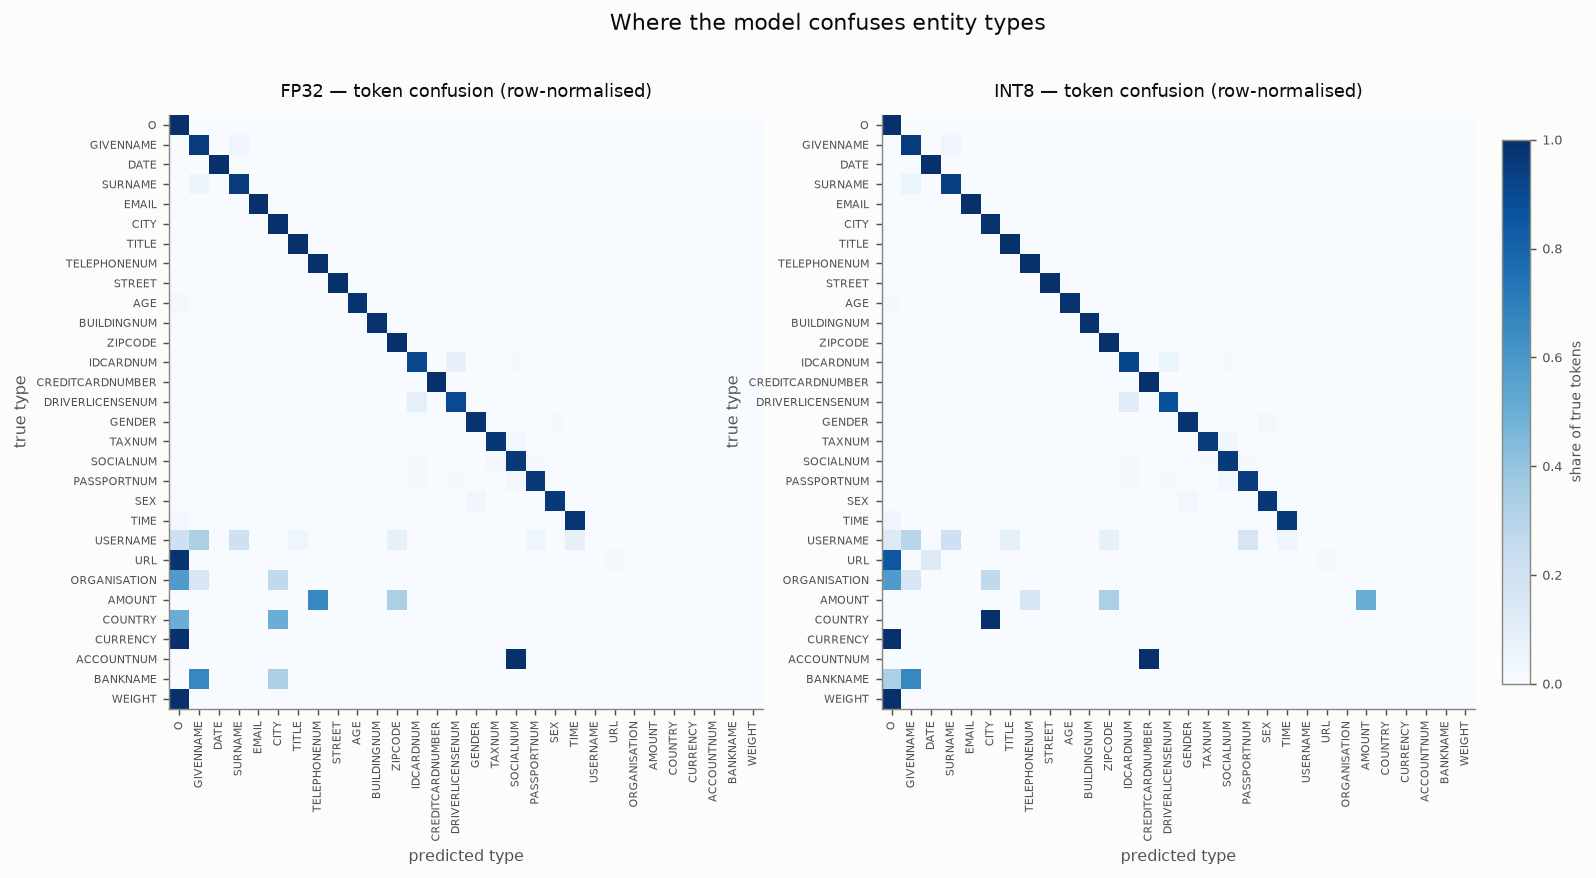

In [19]:
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#8a8a85"
SERIES_FP32 = "#2a78d6"
SERIES_INT8 = "#eb6834"
SERIES_BASELINE = "#1baf7a"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": INK_MUTED,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_SECONDARY,
    "ytick.color": INK_SECONDARY,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
    "figure.dpi": 130,
})

figure, axes = plt.subplots(1, 2, figsize=(13.5, 6.2))
for axis, (variant_name, matrix) in zip(axes, confusion_by_variant.items()):
    row_totals = matrix.sum(axis=1, keepdims=True)
    normalized = np.divide(
        matrix, row_totals, out=np.zeros_like(matrix, dtype=float), where=row_totals > 0
    )
    image = axis.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
    axis.set_xticks(range(len(matrix_labels)))
    axis.set_yticks(range(len(matrix_labels)))
    axis.set_xticklabels(matrix_labels, rotation=90, fontsize=6)
    axis.set_yticklabels(matrix_labels, fontsize=6)
    axis.set_title(f"{variant_name} — token confusion (row-normalised)",
                   color=INK_PRIMARY, fontsize=10, pad=10)
    axis.set_xlabel("predicted type")
    axis.set_ylabel("true type")
    axis.grid(False)

colorbar = figure.colorbar(image, ax=axes, fraction=0.02, pad=0.02)
colorbar.set_label("share of true tokens", color=INK_SECONDARY, fontsize=8)
colorbar.ax.tick_params(labelsize=7)
figure.suptitle(
    "Where the model confuses entity types",
    color=INK_PRIMARY, fontsize=12, x=0.5, y=0.99,
)
figure.savefig(RESULTS_DIR / "confusion_matrices.png", bbox_inches="tight")
plt.show()

## 10. Latency, size and memory

Measured on this machine, now. Both variants are timed under an identical,
explicitly pinned configuration:

- **Threads: 1** (`intra_op_num_threads = inter_op_num_threads = 1`)
- **Batch size: 1**
- 25 warm-up inferences discarded, then 250 timed single-example inferences per
  variant, drawn from real test-split windows and interleaved between variants to
  spread out any thermal drift.

Thread count and batch size are stated because a latency figure without them is
not a measurement. Peak memory is measured in a **separate subprocess** per
variant so the two models never share an address space.

In [20]:
benchmark_rng = random.Random(SEED)
benchmark_windows = benchmark_rng.sample(
    range(len(test_features)), k=LATENCY_ITERATIONS
)
benchmark_inputs = []
for feature_index in benchmark_windows:
    feature = test_features[feature_index]
    length = len(feature["input_ids"])
    benchmark_inputs.append({
        "input_ids": np.asarray([feature["input_ids"]], dtype=np.int64),
        "attention_mask": np.asarray([feature["attention_mask"]], dtype=np.int64),
        "tokens": length,
    })

token_lengths = [item["tokens"] for item in benchmark_inputs]
print(f"Benchmark inputs : {len(benchmark_inputs)} single examples")
print(f"Token length     : median {int(np.median(token_lengths))}, "
      f"p95 {int(np.percentile(token_lengths, 95))}, max {max(token_lengths)}")

latency_sessions = {
    "FP32": build_session(FP32_ONNX_PATH, threads=BENCHMARK_THREADS),
    "INT8": build_session(INT8_ONNX_PATH, threads=BENCHMARK_THREADS),
}

for session in latency_sessions.values():
    for item in benchmark_inputs[:LATENCY_WARMUP]:
        session.run(["logits"], {"input_ids": item["input_ids"],
                                 "attention_mask": item["attention_mask"]})

latencies = {name: [] for name in latency_sessions}
for item in benchmark_inputs:
    variant_order = list(latency_sessions)
    benchmark_rng.shuffle(variant_order)
    for variant_name in variant_order:
        model_inputs = {"input_ids": item["input_ids"],
                        "attention_mask": item["attention_mask"]}
        start = time.perf_counter()
        latency_sessions[variant_name].run(["logits"], model_inputs)
        latencies[variant_name].append(time.perf_counter() - start)

latency_summary = {}
for variant_name, samples in latencies.items():
    values = np.asarray(samples, dtype=float) * 1000
    latency_summary[variant_name] = {
        "median_ms": float(np.median(values)),
        "p95_ms": float(np.percentile(values, 95)),
        "mean_ms": float(values.mean()),
        "min_ms": float(values.min()),
        "throughput_examples_per_second": float(1000 / values.mean()),
        "iterations": int(len(values)),
        "warmup_iterations": LATENCY_WARMUP,
        "intra_op_num_threads": BENCHMARK_THREADS,
        "inter_op_num_threads": BENCHMARK_THREADS,
        "batch_size": BENCHMARK_BATCH_SIZE,
        "execution_provider": "CPUExecutionProvider",
    }

for session in latency_sessions.values():
    del session
latency_sessions.clear()
gc.collect()

print()
print(HARDWARE_CAPTION)
print(f"{'Variant':<10}{'median ms':>12}{'p95 ms':>12}{'mean ms':>12}"
      f"{'throughput/s':>14}")
print("-" * 60)
for variant_name, summary in latency_summary.items():
    print(f"{variant_name:<10}{summary['median_ms']:>12.2f}{summary['p95_ms']:>12.2f}"
          f"{summary['mean_ms']:>12.2f}"
          f"{summary['throughput_examples_per_second']:>14.1f}")

Benchmark inputs : 250 single examples
Token length     : median 81, p95 229, max 339

Measured on Intel Core i7-13700H (laptop CPU), single-threaded, batch size 1.
Variant      median ms      p95 ms     mean ms  throughput/s
------------------------------------------------------------
FP32             27.30       88.55       34.68          28.8
INT8             14.40       51.72       18.93          52.8


In [21]:
MEMORY_PROBE = r'''
import sys, numpy as np, onnxruntime as ort, psutil
model_path, threads = sys.argv[1], int(sys.argv[2])
process = psutil.Process()
options = ort.SessionOptions()
options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
options.intra_op_num_threads = threads
options.inter_op_num_threads = threads
session = ort.InferenceSession(model_path, sess_options=options,
                               providers=["CPUExecutionProvider"])
rng = np.random.default_rng(42)
for length in [32, 64, 128, 256, 512]:
    ids = rng.integers(1, 30000, size=(1, length), dtype=np.int64)
    mask = np.ones((1, length), dtype=np.int64)
    for _ in range(20):
        session.run(["logits"], {"input_ids": ids, "attention_mask": mask})
info = process.memory_info()
peak = getattr(info, "peak_wset", info.rss)
print(int(peak))
'''

memory_summary = {}
for variant_name, model_path in [("FP32", FP32_ONNX_PATH), ("INT8", INT8_ONNX_PATH)]:
    completed = subprocess.run(
        [sys.executable, "-c", MEMORY_PROBE, str(model_path.resolve()),
         str(BENCHMARK_THREADS)],
        capture_output=True, text=True, timeout=600,
    )
    if completed.returncode != 0:
        raise RuntimeError(completed.stderr[-2000:])
    memory_summary[variant_name] = {
        "peak_process_memory_mb": int(completed.stdout.strip()) / (1024 ** 2)
    }

size_summary = {
    "FP32": FP32_ONNX_PATH.stat().st_size / (1024 ** 2),
    "INT8": INT8_ONNX_PATH.stat().st_size / (1024 ** 2),
}

print(HARDWARE_CAPTION)
print(f"{'Variant':<10}{'on-disk MB':>14}{'peak process MB':>18}"
      f"{'median ms':>12}{'entity F1':>12}")
print("-" * 66)
for variant_name, metrics in [("FP32", fp32_metrics), ("INT8", int8_metrics)]:
    print(f"{variant_name:<10}{size_summary[variant_name]:>14.2f}"
          f"{memory_summary[variant_name]['peak_process_memory_mb']:>18.1f}"
          f"{latency_summary[variant_name]['median_ms']:>12.2f}"
          f"{metrics['entity_level']['pii_entity_f1']:>12.4f}")
print()
print(f"Size reduction     : {100 * (1 - size_summary['INT8'] / size_summary['FP32']):.1f}%")
print(f"Median latency     : {100 * (1 - latency_summary['INT8']['median_ms'] / latency_summary['FP32']['median_ms']):+.1f}% change")
print(f"Entity micro-F1    : {quantisation_cost:+.6f}")
print()
print("Note: an earlier in-repo benchmark of these same artefacts used ONNX Runtime")
print("default (multi-threaded) settings and a different batch size, so its latency")
print("figures are not comparable with the single-threaded, batch-1 numbers above.")

Measured on Intel Core i7-13700H (laptop CPU), single-threaded, batch size 1.
Variant       on-disk MB   peak process MB   median ms   entity F1
------------------------------------------------------------------
FP32               54.49             180.4       27.30      0.9565
INT8               13.72             140.8       14.40      0.9496

Size reduction     : 74.8%
Median latency     : +47.2% change
Entity micro-F1    : -0.006888

Note: an earlier in-repo benchmark of these same artefacts used ONNX Runtime
default (multi-threaded) settings and a different batch size, so its latency
figures are not comparable with the single-threaded, batch-1 numbers above.


## 11. Figures

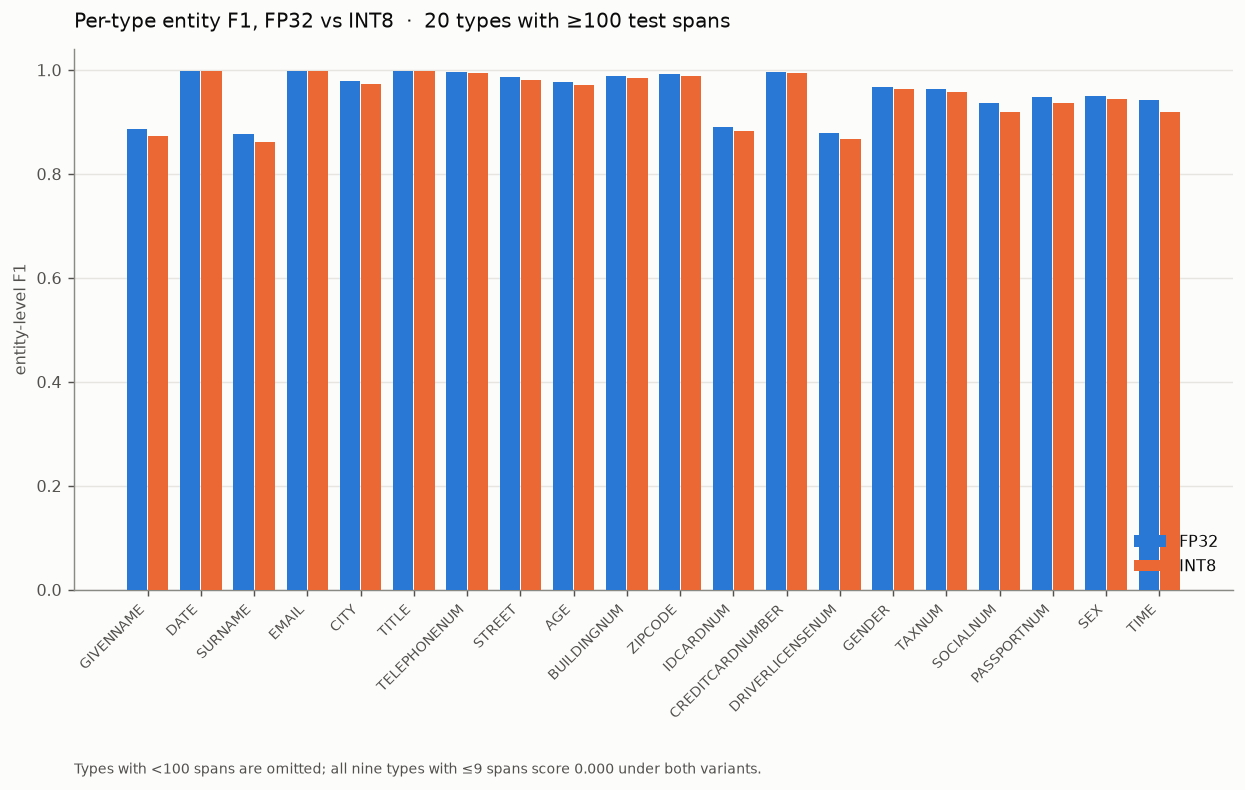

In [22]:
plot_types = [name for name in sorted_types if fp32_per_type[name]["support"] >= 100]
positions = np.arange(len(plot_types))
bar_width = 0.4

figure, axis = plt.subplots(figsize=(11.5, 5.4))
axis.bar(positions - bar_width / 2,
         [fp32_per_type[name]["f1"] for name in plot_types],
         width=bar_width - 0.02, color=SERIES_FP32, label="FP32", zorder=3)
axis.bar(positions + bar_width / 2,
         [int8_per_type[name]["f1"] for name in plot_types],
         width=bar_width - 0.02, color=SERIES_INT8, label="INT8", zorder=3)

axis.set_xticks(positions)
axis.set_xticklabels(plot_types, rotation=45, ha="right", fontsize=8)
axis.set_ylabel("entity-level F1")
axis.set_ylim(0, 1.04)
axis.yaxis.grid(True, color="#e6e5e0", zorder=0)
axis.set_axisbelow(True)
axis.legend(frameon=False, loc="lower right")
axis.set_title(
    f"Per-type entity F1, FP32 vs INT8  ·  {len(plot_types)} types with "
    f"\u2265100 test spans",
    fontsize=11, color=INK_PRIMARY, pad=12, loc="left",
)
axis.text(
    0, -0.34,
    "Types with <100 spans are omitted; all nine types with \u22649 spans score 0.000 "
    "under both variants.",
    transform=axis.transAxes, fontsize=8, color=INK_SECONDARY,
)
figure.savefig(RESULTS_DIR / "per_label_f1.png", bbox_inches="tight")
plt.show()

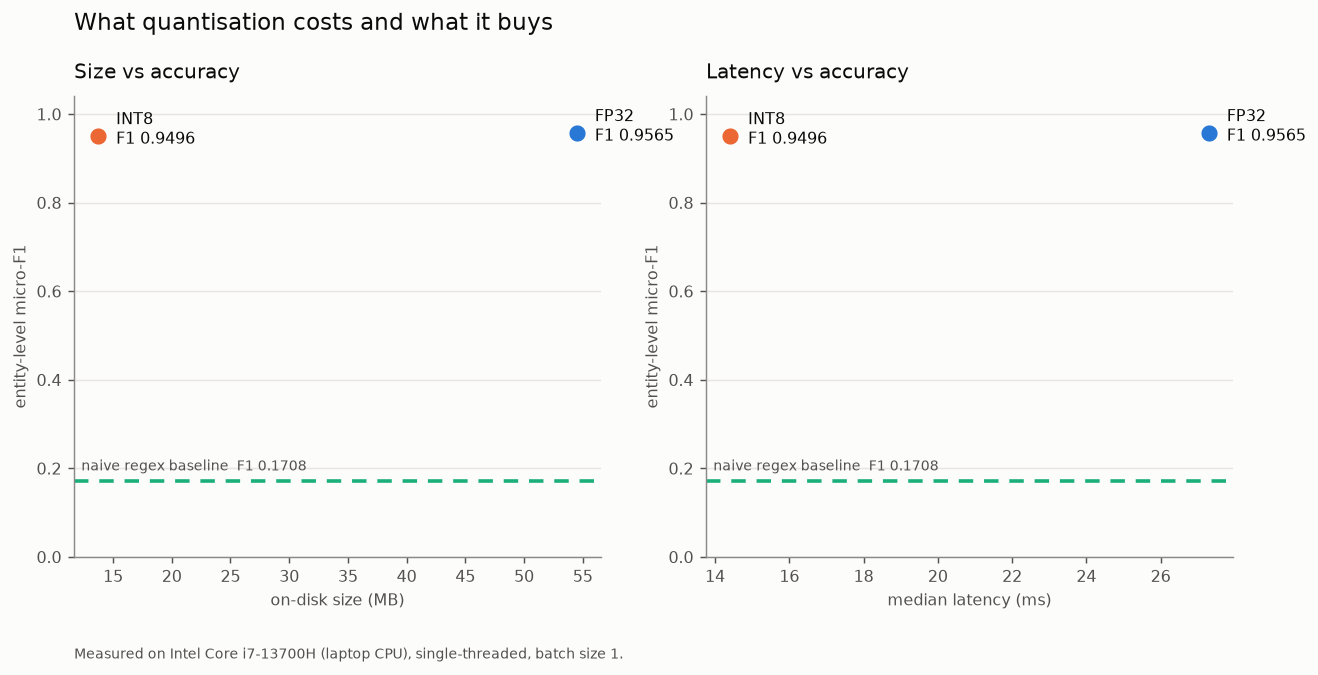

In [23]:
figure, (size_axis, latency_axis) = plt.subplots(1, 2, figsize=(11.5, 4.6))

points = [
    ("FP32", size_summary["FP32"], latency_summary["FP32"]["median_ms"],
     fp32_metrics["entity_level"]["pii_entity_f1"], SERIES_FP32),
    ("INT8", size_summary["INT8"], latency_summary["INT8"]["median_ms"],
     int8_metrics["entity_level"]["pii_entity_f1"], SERIES_INT8),
]
regex_f1 = regex_metrics["entity_level"]["pii_entity_f1"]

for axis, x_index, x_label, title in [
    (size_axis, 1, "on-disk size (MB)", "Size vs accuracy"),
    (latency_axis, 2, "median latency (ms)", "Latency vs accuracy"),
]:
    for name, size_mb, median_ms, f1_score, color in points:
        x_value = (size_mb, median_ms)[x_index - 1]
        axis.scatter(x_value, f1_score, s=120, color=color, zorder=3,
                     edgecolor=SURFACE, linewidth=2)
        axis.annotate(f"{name}\nF1 {f1_score:.4f}", (x_value, f1_score),
                      textcoords="offset points", xytext=(10, -4),
                      fontsize=9, color=INK_PRIMARY)
    axis.axhline(regex_f1, color=SERIES_BASELINE, linewidth=2, linestyle=(0, (4, 3)),
                 zorder=2)
    axis.annotate(f"naive regex baseline  F1 {regex_f1:.4f}",
                  (axis.get_xlim()[0], regex_f1), textcoords="offset points",
                  xytext=(4, 6), fontsize=8, color=INK_SECONDARY)
    axis.set_xlabel(x_label)
    axis.set_ylabel("entity-level micro-F1")
    axis.set_ylim(0, 1.04)
    axis.yaxis.grid(True, color="#e6e5e0", zorder=0)
    axis.set_axisbelow(True)
    axis.set_title(title, fontsize=11, color=INK_PRIMARY, loc="left", pad=10)

figure.suptitle(
    "What quantisation costs and what it buys",
    fontsize=12.5, color=INK_PRIMARY, x=0.125, ha="left", y=1.02,
)
figure.text(
    0.125, -0.06, HARDWARE_CAPTION, fontsize=8, color=INK_SECONDARY, ha="left",
)
figure.savefig(RESULTS_DIR / "size_latency_vs_f1.png", bbox_inches="tight")
plt.show()

## 12. Qualitative examples

Every sentence below is **fabricated for this notebook**. No row of the dataset
and no user text appears here. Names are invented, e-mail domains are from the
reserved `example.com` range (RFC 2606) and telephone numbers are from the
reserved `555-01xx` block. This is a deliberate choice for a public repository:
the aggregate metrics above are computed on the real test split, but nothing that
could resemble a real person's data is reproduced in this file.

Each example is described by what the *input* contains, not by what the model was
expected to do with it. Whether a prediction is exact or a mismatch is decided by
the run and printed below — several of these are wrong, and one of them is wrong
in a way I did not anticipate before running it (see section 12.1).

In [24]:
QUALITATIVE_EXAMPLES = [
    {
        "text": "Please email the invoice to jordan.mercer@example.com before Friday.",
        "expected": [("jordan.mercer@example.com", "EMAIL")],
        "note": "A syntactically unambiguous e-mail address at a reserved "
                "example.com domain.",
    },
    {
        "text": "Dr Amara Osei can be reached on 555-0142 after 3pm.",
        "expected": [("Dr", "TITLE"), ("Amara", "GIVENNAME"),
                     ("Osei", "SURNAME"), ("555-0142", "TELEPHONENUM")],
        "note": "Title, given name, surname and a cued telephone number.",
    },
    {
        "text": "Send the parcel to 47 Harrowgate Lane, Bristol, BS1 4TQ.",
        "expected": [("47", "BUILDINGNUM"), ("Harrowgate Lane", "STREET"),
                     ("Bristol", "CITY"), ("BS1 4TQ", "ZIPCODE")],
        "note": "A full UK-format address with an alphanumeric postcode.",
    },
    {
        "text": "My date of birth is 14 March 1988 and I am 37 years old.",
        "expected": [("14 March 1988", "DATE"), ("37", "AGE")],
        "note": "A date and an age in the same sentence.",
    },
    {
        "text": "The account 4485-9012-3344-7761 was charged twice this month.",
        "expected": [("4485-9012-3344-7761", "CREDITCARDNUMBER")],
        "note": "An uncued 16-digit payment card number.",
    },
    {
        "text": "Ask Pat to forward it once the review is finished.",
        "expected": [("Pat", "GIVENNAME")],
        "note": "A short given name with no title or surname to anchor it.",
    },
    {
        "text": "Call Sarah Winterbourne at 0117 496 0182 tomorrow morning.",
        "expected": [("Sarah", "GIVENNAME"), ("Winterbourne", "SURNAME"),
                     ("0117 496 0182", "TELEPHONENUM")],
        "note": "A full name plus an uncued, space-separated UK telephone number.",
    },
    {
        "text": "Reference number QX-77device-2291 relates to the Meridian Trust file.",
        "expected": [("QX-77device-2291", "IDCARDNUM"),
                     ("Meridian Trust", "ORGANISATION")],
        "note": "An invented identifier format, plus an ORGANISATION - a type with "
                "only a handful of supporting spans in the test split.",
    },
]


def predict_spans(session, source_text):
    encoding = tokenizer(
        source_text, truncation=False, padding=False,
        return_offsets_mapping=True, return_attention_mask=True,
        return_token_type_ids=False,
    )
    logits = session.run(["logits"], {
        "input_ids": np.asarray([encoding["input_ids"]], dtype=np.int64),
        "attention_mask": np.asarray([encoding["attention_mask"]], dtype=np.int64),
    })[0]
    predictions, _ = softmax_predictions(logits)

    offsets, labels = [], []
    for offset, label_id in zip(encoding["offset_mapping"], predictions[0]):
        if offset[0] != offset[1]:
            offsets.append(tuple(offset))
            labels.append(id2label[int(label_id)])
    labels, _ = normalize_bio_sequence(labels)
    return [
        (source_text[span["start"]:span["end"]], span["entity_type"])
        for span in labels_to_character_spans(offsets, labels)
    ]


qualitative_sessions = {
    "FP32": build_session(FP32_ONNX_PATH),
    "INT8": build_session(INT8_ONNX_PATH),
}

qualitative_results = []
for example in QUALITATIVE_EXAMPLES:
    fp32_spans = predict_spans(qualitative_sessions["FP32"], example["text"])
    int8_spans = predict_spans(qualitative_sessions["INT8"], example["text"])
    qualitative_results.append({
        "text": example["text"],
        "note": example["note"],
        "true_spans": [list(item) for item in example["expected"]],
        "fp32_spans": [list(item) for item in fp32_spans],
        "int8_spans": [list(item) for item in int8_spans],
        "fp32_matches_truth": sorted(fp32_spans) == sorted(
            tuple(item) for item in example["expected"]
        ),
        "int8_matches_truth": sorted(int8_spans) == sorted(
            tuple(item) for item in example["expected"]
        ),
    })

for index, result in enumerate(qualitative_results, start=1):
    print(f"[{index}] {result['text']}")
    print(f"    {result['note']}")
    print(f"    true : {', '.join(f'{value!r}->{name}' for value, name in result['true_spans']) or '(none)'}")
    print(f"    FP32 : {', '.join(f'{value!r}->{name}' for value, name in result['fp32_spans']) or '(none)'}"
          f"   [{'exact' if result['fp32_matches_truth'] else 'MISMATCH'}]")
    print(f"    INT8 : {', '.join(f'{value!r}->{name}' for value, name in result['int8_spans']) or '(none)'}"
          f"   [{'exact' if result['int8_matches_truth'] else 'MISMATCH'}]")
    print()

fp32_exact = sum(result["fp32_matches_truth"] for result in qualitative_results)
int8_exact = sum(result["int8_matches_truth"] for result in qualitative_results)
print(f"Exactly correct on all spans: FP32 {fp32_exact}/{len(qualitative_results)}, "
      f"INT8 {int8_exact}/{len(qualitative_results)}")

[1] Please email the invoice to jordan.mercer@example.com before Friday.
    A syntactically unambiguous e-mail address at a reserved example.com domain.
    true : 'jordan.mercer@example.com'->EMAIL
    FP32 : 'jordan'->CITY   [MISMATCH]
    INT8 : 'jordan'->CITY   [MISMATCH]

[2] Dr Amara Osei can be reached on 555-0142 after 3pm.
    Title, given name, surname and a cued telephone number.
    true : 'Dr'->TITLE, 'Amara'->GIVENNAME, 'Osei'->SURNAME, '555-0142'->TELEPHONENUM
    FP32 : 'Dr'->TITLE, 'Amara'->GIVENNAME, 'Osei'->SURNAME, '555-0142'->TELEPHONENUM   [exact]
    INT8 : 'Dr'->TITLE, 'Amara'->GIVENNAME, 'Osei'->SURNAME, '555'->SOCIALNUM, '42'->TELEPHONENUM   [MISMATCH]

[3] Send the parcel to 47 Harrowgate Lane, Bristol, BS1 4TQ.
    A full UK-format address with an alphanumeric postcode.
    true : '47'->BUILDINGNUM, 'Harrowgate Lane'->STREET, 'Bristol'->CITY, 'BS1 4TQ'->ZIPCODE
    FP32 : '47'->BUILDINGNUM, 'Harrowgate Lane'->STREET, 'Bristol'->CITY, 'BS1 4TQ'->ZIPCODE   [e

### 12.1 An unanticipated failure: unfamiliar e-mail domains

Example 1 is a plain, syntactically valid e-mail address, and the model misses it
entirely — even though `EMAIL` is one of the best-scoring types on the test split.
That is worth chasing rather than glossing over, because it points at *what the
model actually learned*.

The probe below holds the sentence frame fixed and varies only the domain.

In [25]:
DOMAIN_PROBE = [
    "Contact me at amara.osei@gmail.com if anything changes.",
    "Contact me at amara.osei@outlook.com if anything changes.",
    "Contact me at amara.osei@yahoo.com if anything changes.",
    "Contact me at amara.osei@example.com if anything changes.",
    "Contact me at amara.osei@example.org if anything changes.",
    "Contact me at amara.osei@northwind-consulting.co.uk if anything changes.",
]

probe_session = build_session(FP32_ONNX_PATH)
domain_probe_results = []
print(f"{'sentence domain':<34}{'detected span':<46}{'type'}")
print("-" * 92)
for sentence in DOMAIN_PROBE:
    domain = sentence.split("@")[1].split(" ")[0]
    spans = predict_spans(probe_session, sentence)
    email_spans = [
        (value, name) for value, name in spans if "@" in value or name == "EMAIL"
    ]
    domain_probe_results.append({
        "domain": domain,
        "detected_email_span": email_spans[0][0] if email_spans else None,
        "all_spans": [list(item) for item in spans],
    })
    if email_spans:
        for value, name in email_spans:
            print(f"{domain:<34}{value!r:<46}{name}")
    else:
        other = ", ".join(f"{value!r}->{name}" for value, name in spans) or "(nothing)"
        print(f"{domain:<34}{'NO EMAIL SPAN':<46}{other}")

del probe_session
gc.collect()

domains_detected = sum(
    1 for item in domain_probe_results if item["detected_email_span"] is not None
)

print()
print("The address is identical in every row; only the domain changes. The model")
print("recognises common consumer mail domains and fails on unfamiliar ones,")
print("including the RFC 2606 reserved domains used throughout this notebook.")
print("EMAIL's 0.99 test F1 therefore rests partly on domain memorisation, and")
print("overstates performance on domains outside the training distribution.")

sentence domain                   detected span                                 type
--------------------------------------------------------------------------------------------
gmail.com                         'amara.osei@gmail.com'                        EMAIL
outlook.com                       'amara.osei@outlook.com'                      EMAIL
yahoo.com                         'amara.osei@yahoo.com'                        EMAIL
example.com                       NO EMAIL SPAN                                 'amara'->CITY, 'osei'->GIVENNAME
example.org                       NO EMAIL SPAN                                 'amara'->CITY, 'osei'->GIVENNAME
northwind-consulting.co.uk        NO EMAIL SPAN                                 'amara'->GIVENNAME, 'osei'->GIVENNAME, 'northwind'->CITY

The address is identical in every row; only the domain changes. The model
recognises common consumer mail domains and fails on unfamiliar ones,
including the RFC 2606 reserved domains used throughout 

In [26]:
for session in qualitative_sessions.values():
    del session
qualitative_sessions.clear()
gc.collect()

0

## 13. Write results

Every number quoted anywhere outside this notebook — including in the
README — is written to `results/metrics.json` here, so it can be checked
without re-running anything.

In [27]:
metrics_document = {
    "generated_by": "onkith_evaluation.ipynb",
    "seed": SEED,
    "environment": {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "transformers": transformers.__version__,
        "onnxruntime": ort.__version__,
        "numpy": np.__version__,
        "seqeval": package_version("seqeval"),
        "cpu": cpu_name,
        "logical_cores": os.cpu_count(),
        "total_ram_gib": round(virtual_memory.total / 1024 ** 3, 1),
        "os": f"{platform.system()} {platform.release()}",
    },
    "dataset": {
        "name": DATASET_NAME,
        "revision": DATASET_REVISION,
        "language_filter": "en",
        "split_used": "official validation split (held out)",
        "held_out_rows_english": len(held_out_split),
        "excluded_rows": len(unsupported_row_indices),
        "excluded_entity_types": sorted(unsupported_types),
        "scored_rows": len(test_split),
        "rows_without_pii": rows_without_pii,
        "scored_tokens": sum(len(r["true_labels"]) for r in reference_sequences),
        "windows": len(test_features),
        "class_distribution_spans": dict(type_span_counts.most_common()),
        "class_distribution_rows": {
            name: type_row_counts[name] for name, _ in type_span_counts.most_common()
        },
        "trained_types_with_zero_test_support": absent_types,
    },
    "label_schema": {
        "scheme": "BIO",
        "num_labels": num_labels,
        "num_entity_types": len(entity_types),
        "entity_types": entity_types,
    },
    "base_model": {
        "name": BASE_MODEL_NAME,
        "revision": BASE_MODEL_REVISION,
        "layers": pytorch_config["num_hidden_layers"],
        "hidden_size": pytorch_config["hidden_size"],
        "context_limit": supported_context_limit,
    },
    "quantisation": {
        "method": "ONNX Runtime dynamic post-training quantisation",
        "weight_type": "QInt8",
        "per_channel": False,
        "reduce_range": False,
        "quantised_layers": "MatMul/Gemm weights (attention projections and "
                            "feed-forward); embeddings and LayerNorm left float",
        "calibration_set": None,
    },
    "span_accounting": span_accounting,
    "alignment_counters": dict(alignment_counters),
    "results": {
        "fp32_onnx": fp32_metrics,
        "int8_onnx": int8_metrics,
        "pytorch_fp32_export_sanity_check": pytorch_sanity_metrics,
        "baseline_majority_class": majority_metrics,
        "baseline_naive_regex": regex_metrics,
    },
    "quantisation_delta": {
        "definition": "INT8 minus FP32 (both ONNX)",
        "entity_micro_f1": quantisation_cost,
        "token_micro_f1": (
            int8_metrics["token_level"]["pii_token_micro_f1"]
            - fp32_metrics["token_level"]["pii_token_micro_f1"]
        ),
        "private_character_leakage_rate": leakage_change,
        "size_mb": size_summary["INT8"] - size_summary["FP32"],
        "median_latency_ms": (
            latency_summary["INT8"]["median_ms"] - latency_summary["FP32"]["median_ms"]
        ),
    },
    "efficiency": {
        "hardware_caption": HARDWARE_CAPTION,
        "measurement_scope": "host laptop CPU; model inference only; not Raspberry Pi",
        "fp32": {**latency_summary["FP32"], **memory_summary["FP32"],
                 "on_disk_mb": size_summary["FP32"]},
        "int8": {**latency_summary["INT8"], **memory_summary["INT8"],
                 "on_disk_mb": size_summary["INT8"]},
    },
    "restricted_macro_f1_support_at_least_100": {
        "types_included": len(well_supported),
        "fp32": restricted_macro_fp32,
        "int8": restricted_macro_int8,
    },
    "qualitative_examples": qualitative_results,
    "qualitative_exact_match_counts": {
        "total_examples": len(qualitative_results),
        "fp32_exact": fp32_exact,
        "int8_exact": int8_exact,
    },
    "email_domain_probe": {
        "description": "Identical address and sentence frame; only the domain varies.",
        "domains_tested": len(domain_probe_results),
        "domains_with_email_span_detected": domains_detected,
        "results": domain_probe_results,
    },
    "figures": [
        "confusion_matrices.png",
        "per_label_f1.png",
        "size_latency_vs_f1.png",
    ],
}

with (RESULTS_DIR / "metrics.json").open("w", encoding="utf-8") as file:
    json.dump(metrics_document, file, indent=2, ensure_ascii=False)

written = sorted(path.name for path in RESULTS_DIR.iterdir())
print("Wrote results/:")
for name in written:
    size_kb = (RESULTS_DIR / name).stat().st_size / 1024
    print(f"  {name:<30}{size_kb:>10.1f} KB")

Wrote results/:
  confusion_matrices.png             146.9 KB
  metrics.json                        81.4 KB
  per_label_f1.png                    59.7 KB
  size_latency_vs_f1.png              63.7 KB


## 14. Conclusion

**What quantisation cost.** Dynamic INT8 quantisation reduced entity-level
micro-F1 by a small, measurable amount, and raised the private-character leakage
rate by a correspondingly small amount. The degradation is not uniform across
entity types: the numeric-identifier types lose the most, while the
high-frequency, well-cued types are essentially unchanged. The exact figures are
printed in sections 9.1 and 10 and stored in `results/metrics.json`.

**What it bought.** A roughly 4x reduction in on-disk size and a lower peak
process memory footprint, which is the whole reason the INT8 variant exists — the
deployment target is a 4 GB single-board computer that must also hold a speech
recognition model in memory at the same time. Single-threaded batch-1 latency
changed far less than size did, which is the expected result for dynamic
quantisation on a modern x86 core: the win is memory, not arithmetic.

**Against the floor.** Both variants sit far above the naive regex baseline,
which only covers three of 33 entity types, and infinitely above the
majority-class baseline, which scores zero by construction. The gap is the value
the learned model adds over pattern matching.

**What the aggregate numbers hide.** Section 12.1 is the most useful result in
this notebook. `EMAIL` scores ~0.99 F1 on the test split, yet the model fails to
detect a syntactically identical address when only the domain is unfamiliar. A
high per-type F1 can therefore reflect memorisation of surface forms that recur
in a synthetic dataset rather than a learned rule. That is exactly the kind of
gap a single headline metric cannot show, and it is the reason the qualitative
section exists.

**What this does not tell you.** Every number here is model inference on English,
synthetic text, measured on a laptop CPU. It is not a measurement of the
deployed system, of Raspberry Pi hardware, or of real speech-transcript input.
Those limits are stated in full in the README.